### Tissera Ana Paula - `Notebook TP4`

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Imports

In [37]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import pandas as pd

In [38]:
# uso de cupy en vez de numpy para correrlo en GPU
import cupy as cp

device_id = cp.cuda.Device().id
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [39]:
SEED = 42

## `1.` **Clustering de datos**

##### Cargar los datos

In [40]:
clustering_path = "data/clustering.csv"
clustering_df = pd.read_csv(clustering_path)

##### Visualización de ejemplo

In [41]:
clustering_df.sample(5, random_state=SEED)

,Unnamed: 0,A,B
84,84,822368,648690
2470,2470,954037,754046
2804,2804,640123,716370
4987,4987,772586,123935
4924,4924,598444,128607


In [42]:
clustering_df = clustering_df.drop(clustering_df.columns[0], axis=1)

In [43]:
clustering_df.sample(5, random_state=SEED)

,A,B
84,822368,648690
2470,954037,754046
2804,640123,716370
4987,772586,123935
4924,598444,128607


In [44]:
X_cpu = clustering_df.values
X = cp.array(X_cpu)  # pasar a GPU
X = cp.array(clustering_df.values)

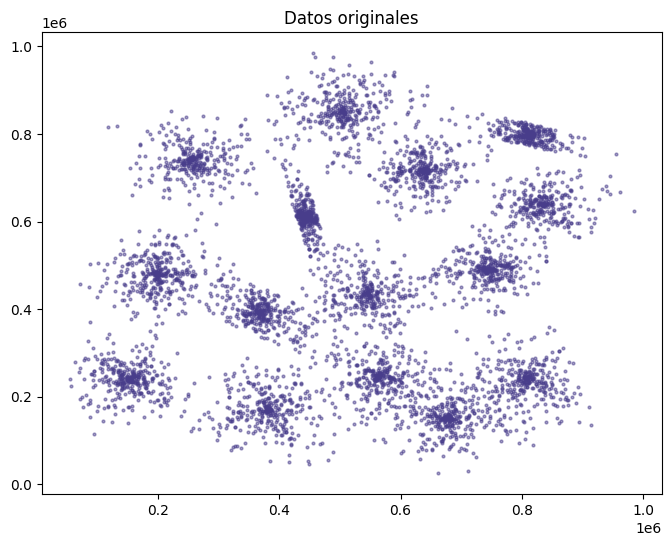

In [45]:
plt.figure(figsize=(8, 6))
plt.plot(X_cpu[:, 0], X_cpu[:, 1], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Datos originales")
plt.show()

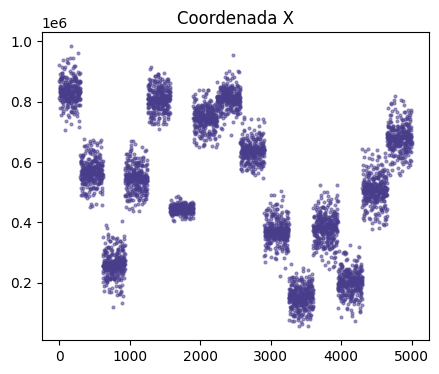

In [46]:
plt.figure(figsize=(5, 4))
plt.plot(X_cpu[:, 0], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Coordenada X")
plt.show()

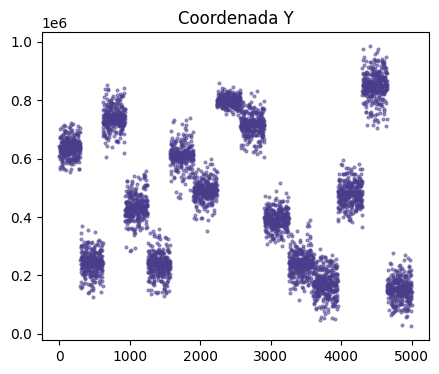

In [47]:
plt.figure(figsize=(5, 4))
plt.plot(X_cpu[:, 1], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Coordenada Y")
plt.show()

### `a.` **K-Means** con ganancias decrecientes para determinar K

In [48]:
from src.models import KMeans
from src.utils import find_elbow

##### $L$ vs. $K$

In [49]:


Ks = list(range(1, 20))
Ls = []
for K in Ks:
    km = KMeans(n_clusters=K, init="k-means++", n_init=10,
                max_iter=300, tol=1e-4, random_state=42)
    km.fit(X)
    print(f"K = {K:2d} → Inercia = {km.distortion_:.2f}")
    Ls.append(km.distortion_)

elbow_idx, distances = find_elbow(Ks, Ls, alpha = 0.0177)
bestK = Ks[elbow_idx]
bestL = Ls[elbow_idx]
print(f"\nEl mejor número de clusters según el método del codo es K = {bestK}")


K =  1 → Inercia = 516864302744182.00
K =  2 → Inercia = 289934063974210.00
K =  3 → Inercia = 182617259354599.00
K =  4 → Inercia = 119781237770822.00
K =  5 → Inercia = 97158902693967.00
K =  6 → Inercia = 79352490290900.00
K =  7 → Inercia = 66442291574055.00
K =  8 → Inercia = 56002180572199.00
K =  9 → Inercia = 45039384213855.00
K = 10 → Inercia = 39506532259043.00
K = 11 → Inercia = 31693774488119.00
K = 12 → Inercia = 24877328816656.00
K = 13 → Inercia = 20833857832204.00
K = 14 → Inercia = 16848986287901.00
K = 15 → Inercia = 13279024047994.00
K = 16 → Inercia = 12878514745437.00
K = 17 → Inercia = 12533515534453.00
K = 18 → Inercia = 12190859497060.00
K = 19 → Inercia = 11827965038787.00

El mejor número de clusters según el método del codo es K = 15


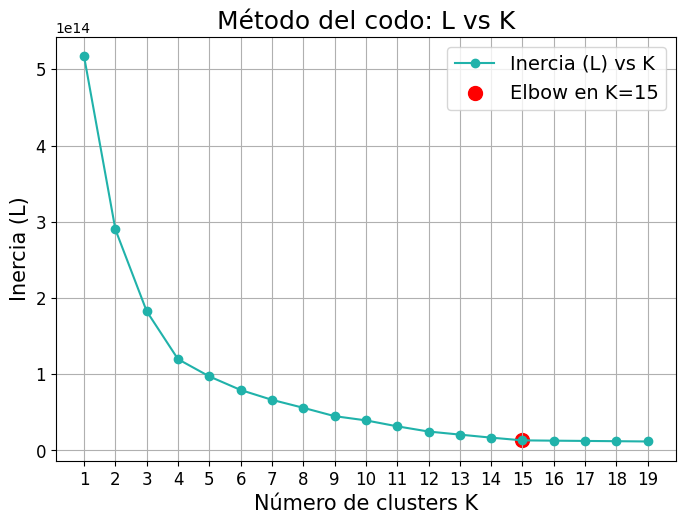

In [50]:
plt.figure(figsize=(8, 5.5))
plt.plot(Ks, Ls, marker='o', label='Inercia (L) vs K', color = "lightseagreen")
plt.scatter([bestK], [bestL], color='red', s=100, label=f'Elbow en K={bestK}')
plt.xlabel("Número de clusters K", fontsize=15)
plt.ylabel("Inercia (L)", fontsize=15)
plt.title("Método del codo: L vs K", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(Ks)
plt.grid(True)
plt.legend(fontsize=14)
plt.show()

In [51]:
km = KMeans(n_clusters=bestK, init="k-means++", n_init=10,
            max_iter=300, tol=1e-4, random_state=42)
labels = km.fit_predict(X)

print(f"Inercia final: {km.distortion_:.2f}")
print(f"Iteraciones en la mejor ejecución: {km.n_iter_}")

Inercia final: 13279024047994.00
Iteraciones en la mejor ejecución: 16


##### Gráfico del conjunto $x_i$

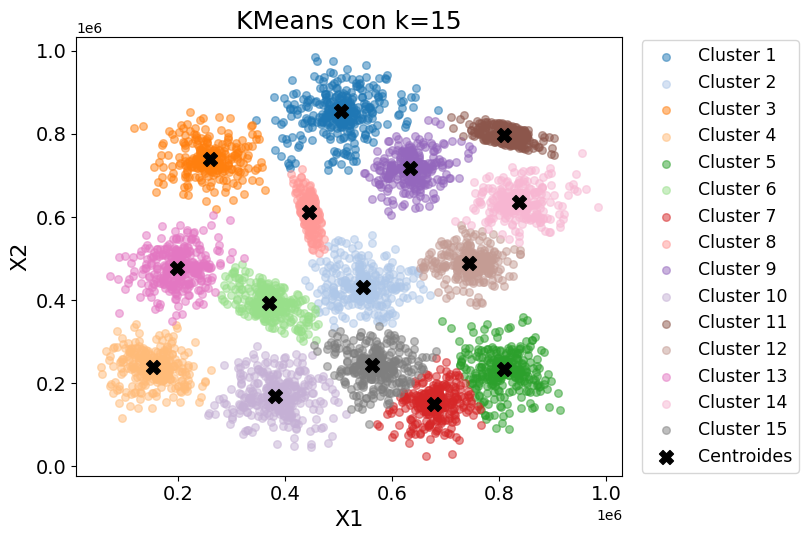

In [114]:
cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)]  # devuelve 20 RGBA distintos


fig, ax = plt.subplots(figsize=(11,5.5))
for k in range(km.n_clusters):
    pts_k = X[labels == k]
    x_k = pts_k[:, 0].get()
    y_k = pts_k[:, 1].get()
    ax.scatter(x_k, y_k, s=30, color=colors[k % 20], label=f"Cluster {k+1}", alpha=0.5)


centers = km.cluster_centers_
cx = centers[:, 0].get()
cy = centers[:, 1].get()
ax.scatter(cx, cy, marker='X', s=100, c='black', label="Centroides")

ax.set_xlabel("X1", fontsize=16)
ax.set_ylabel("X2", fontsize=16)
ax.set_title(f"KMeans con k={km.n_clusters}", fontsize=18)
#?
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)


ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=12.5)

plt.tight_layout(rect=(0,0,0.75,1))
plt.show()

In [53]:
import numpy as np

In [54]:
# Crear array NumPy de shape (K, 2)
means_GMM = np.vstack([km.cluster_centers_[k].get() for k in range(bestK)])
df_means = pd.DataFrame(means_GMM, columns=["X1", "X2"])
df_means.index = [f"Cluster {i+1}" for i in range(bestK)]

print(df_means)

                X1      X2
Cluster 1   503665  854338
Cluster 2   371101  392427
Cluster 3   380160  169091
Cluster 4   545950  432863
Cluster 5   562468  243230
Cluster 6   809538  797406
Cluster 7   677971  150751
Cluster 8   742741  489417
Cluster 9   258855  740048
Cluster 10  808125  234833
Cluster 11  633300  717099
Cluster 12  444512  611892
Cluster 13  152590  239488
Cluster 14  199455  478149
Cluster 15  836493  636549


### `b.`  Gaussian Mixture Model (**GMM**)

##### inicialización de GMM con una corrida de K-means

In [135]:
import matplotlib.pyplot as plt
from src.models import GMM

In [136]:
# 2) Inicializa parámetros con KMeans
km = KMeans(n_clusters=bestK, init="k-means++", n_init=10,
            max_iter=300, tol=1e-4, random_state=42)

labels_k = km.fit_predict(X)
means0 = km.cluster_centers_
counts = cp.bincount(labels_k, minlength=bestK).astype(cp.float64)
weights0 = counts / X.shape[0]
D = X.shape[1]
covs0 = cp.zeros((bestK, D, D), dtype=cp.float64)
for k in range(bestK):
    Xk = X[labels_k == k].astype(cp.float64)
    diff = Xk - means0[k]
    covs0[k] = (diff.T @ diff) / Xk.shape[0] + cp.eye(D, dtype=cp.float64)*1e-6


In [137]:
# 3) Crea y ajusta GMM usando esos init_params
init_params = {'means': means0, 'weights': weights0, 'covs': covs0}

gmm = GMM(n_components=bestK, tol=1e-4, max_iter=100,
            reg_covar=1e-6, random_state=42, init_params=init_params)
labels = gmm.fit_predict(X)
print(f"GMM final con K={bestK}: LL={gmm.log_likelihood_:.2f}, iter={gmm.n_iter_}")


GMM final con K=15: LL=-131948.36, iter=100


In [143]:
from matplotlib.patches import Ellipse
import numpy as np
from scipy.stats import chi2
from matplotlib.colors import to_rgb

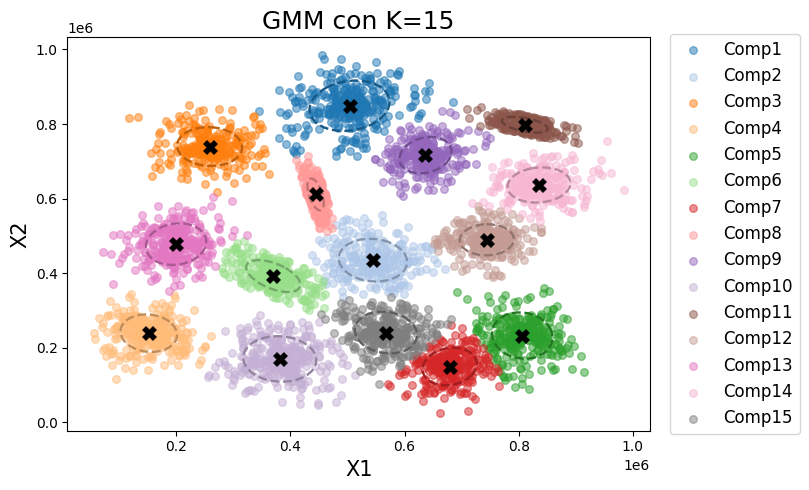

In [160]:
# factor para el 95% de confianza en 2D
factor = np.sqrt(chi2.ppf(0.62, df=2))  

fig, ax = plt.subplots(figsize=(11,5))

# 1) Scatter de puntos
for k in range(bestK):
    pts = X[labels == k]
    x_cpu = pts[:, 0].get()
    y_cpu = pts[:, 1].get()
    ax.scatter(x_cpu, y_cpu, s=30, color=colors[k], alpha=0.5, zorder=1)

# 2) Elipses y medias
for k in range(bestK):
    mean_cpu = gmm.means_[k].get()
    cov_cpu  = gmm.covariances_[k].get()
    if cov_cpu.ndim == 1:
        cov_cpu = np.diag(cov_cpu)

    vals, vecs = np.linalg.eigh(cov_cpu)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width  = 2 * factor * np.sqrt(vals[0])
    height = 2 * factor * np.sqrt(vals[1])
    
    # width  = 2 * np.sqrt(vals[0])
    # height = 2 * np.sqrt(vals[1])

    dark_color = tuple(np.array(to_rgb(colors[k])) * 0.75)

    ellipse = Ellipse(
        xy=mean_cpu,
        width=width, height=height,
        angle=angle,
        edgecolor=dark_color,
        facecolor='none',
        linewidth=1.7,
        linestyle='--',
        zorder=2
    )
    
    ax.add_patch(ellipse)

    # Marcar la media
    ax.scatter(
        mean_cpu[0], mean_cpu[1],
        marker='X', s=100,
        color=colors[k], edgecolor='black', facecolor='black',
        linewidth=0.5,
        zorder=3
    )

# 3) Ajustes finales
ax.set_xlabel("X1", fontsize=15)
ax.set_ylabel("X2", fontsize=15)
ax.set_title(f"GMM con K={bestK}", fontsize=18)
ax.legend([f"Comp{k+1}" for k in range(bestK)],
          loc="center left", bbox_to_anchor=(1.02,0.5), fontsize=12)


plt.tight_layout(rect=(0,0,0.75,1))
plt.show()


In [60]:
import pandas as pd

# Crear array NumPy de shape (K, 2)
means_GMM = np.vstack([gmm.means_[k].get() for k in range(bestK)])
df_means = pd.DataFrame(means_GMM, columns=["X1", "X2"])
df_means.index = [f"Cluster {i+1}" for i in range(bestK)]

print(df_means)


                       X1             X2
Cluster 1   503639.445011  848998.565730
Cluster 2   370046.810416  392366.505896
Cluster 3   381361.066834  170139.184861
Cluster 4   544685.622839  435067.992863
Cluster 5   567524.731561  240980.837211
Cluster 6   810811.488999  798129.772216
Cluster 7   679011.244358  149685.759591
Cluster 8   744174.637727  489608.698710
Cluster 9   258526.838558  739614.490923
Cluster 10  806234.677708  232888.813934
Cluster 11  636710.032028  716633.560039
Cluster 12  444257.555581  611222.244208
Cluster 13  151947.169780  239269.053636
Cluster 14  199769.124974  478031.611482
Cluster 15  835491.527516  636631.840717


### `c.`  **DBSCAN**

In [61]:
from src.models import DBSCAN

##### Variación de los parámetros ε (radio de la vecindad) y $K$ (mínimo número de puntos en una zona densa)

In [63]:
X_cpu = clustering_df.values.astype(float)
X = cp.array(X_cpu)

mean = X.mean(axis=0)
std  = X.std(axis=0)
Xn = (X - mean) / std

eps_list = cp.linspace(0.0, 0.2, 10)                      # 40 valores de ε
min_pts_list = cp.linspace(30, 200, 10, dtype=cp.int32)   # 40 valores de min_samples

# 4) Iniciar arrays de resultados en GPU
clusters = cp.zeros((min_pts_list.size, eps_list.size), dtype=cp.int32)
noise    = cp.zeros_like(clusters)

# 5) Grid search
for i, min_pts in enumerate(min_pts_list):
    for j, eps in enumerate(eps_list):
        db = DBSCAN(eps=float(eps), min_samples=int(min_pts))
        labels = db.fit_predict(Xn)
        labels_cpu = labels.get()
        n_clusters = len(set(labels_cpu.tolist())) - (1 if -1 in labels_cpu else 0)
        n_noise    = int((labels_cpu == -1).sum())
        clusters[i, j] = n_clusters
        noise[i, j]    = n_noise

eps     = cp.asnumpy(eps_list)
min_pts = cp.asnumpy(min_pts_list)
clusters= cp.asnumpy(clusters)
noise   = cp.asnumpy(noise)

E, M = cp.meshgrid(eps_list, min_pts_list)
E_cpu = cp.asnumpy(E).flatten()
M_cpu = cp.asnumpy(M).flatten()


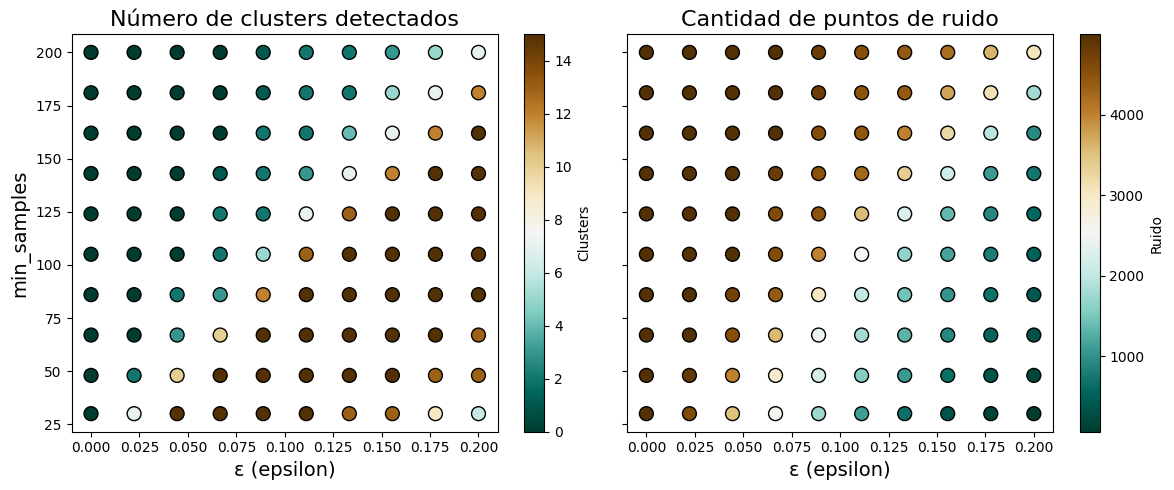

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sc1 = ax1.scatter(
    E_cpu, M_cpu,
    c=clusters.flatten(),
    cmap="BrBG_r",
    s=100,
    edgecolors="k"
)
ax1.set_title("Número de clusters detectados", fontsize=16)
ax1.set_xlabel("ε (epsilon)", fontsize=14)
ax1.set_ylabel("min_samples", fontsize=14)  
fig.colorbar(sc1, ax=ax1, label="Clusters")

sc2 = ax2.scatter(
    E_cpu, M_cpu,
    c=noise.flatten(),
    cmap="BrBG_r", #RdBu_r
    s=100,
    edgecolors="k"
)
ax2.set_title("Cantidad de puntos de ruido", fontsize=16)
ax2.set_xlabel("ε (epsilon)", fontsize=14)
fig.colorbar(sc2, ax=ax2, label="Ruido")

plt.tight_layout()
plt.show()

In [128]:
X_cpu = clustering_df.values.astype(float)
X = cp.array(X_cpu)
mean = X.mean(axis=0)
std  = X.std(axis=0)
Xn = (X - mean) / std

# 2) Traer Xn a CPU una sola vez
Xn_cpu = cp.asnumpy(Xn)

# 3) Definir grid en NumPy
eps_list     = np.linspace(0.0, 0.25, 40)    # 40 valores de eps
min_pts_list = np.linspace(30, 200, 40, dtype=int)  # 40 valores de min_samples

# 4) Arrays de resultados en NumPy
clusters = np.zeros((min_pts_list.size, eps_list.size), dtype=int)
noise    = np.zeros_like(clusters)

# 5) Grid search con DBSCAN+KDTree (CPU)
for i, min_pts in enumerate(min_pts_list):
    for j, eps in enumerate(eps_list):
        # Instancio tu DBSCAN de CPU
        db = DBSCAN(eps=eps, min_samples=min_pts)
        labels = db.fit_predict(Xn_cpu)
        
        # Calcular n_clusters y n_noise
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})
        n_noise    = int((labels == -1).sum())
        
        clusters[i, j] = n_clusters
        noise[i, j]    = n_noise

# 6) Preparar para análisis o visualización
E_cpu = np.repeat(eps_list[np.newaxis, :], min_pts_list.size, axis=0).flatten()
M_cpu = np.repeat(min_pts_list[:, np.newaxis], eps_list.size, axis=1).flatten()

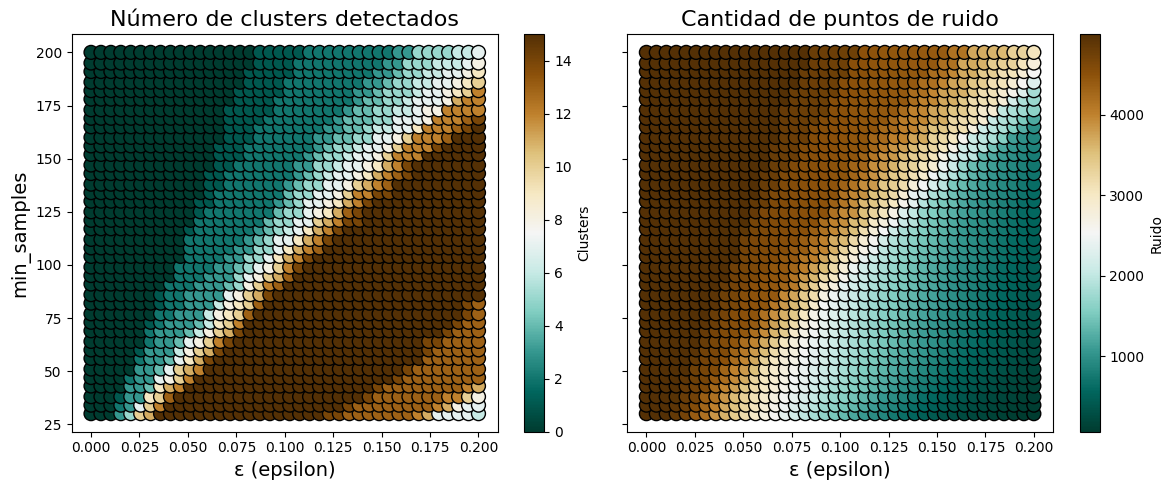

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sc1 = ax1.scatter(
    E_cpu, M_cpu,
    c=clusters.flatten(),
    cmap="BrBG_r",
    s=100,
    edgecolors="k"
)
ax1.set_title("Número de clusters detectados", fontsize=16)
ax1.set_xlabel("ε (epsilon)", fontsize=14)
ax1.set_ylabel("min_samples", fontsize=14)  
fig.colorbar(sc1, ax=ax1, label="Clusters")

sc2 = ax2.scatter(
    E_cpu, M_cpu,
    c=noise.flatten(),
    cmap="BrBG_r", #RdBu_r
    s=100,
    edgecolors="k"
)
ax2.set_title("Cantidad de puntos de ruido", fontsize=16)
ax2.set_xlabel("ε (epsilon)", fontsize=14)
fig.colorbar(sc2, ax=ax2, label="Ruido")

plt.tight_layout()
plt.show()

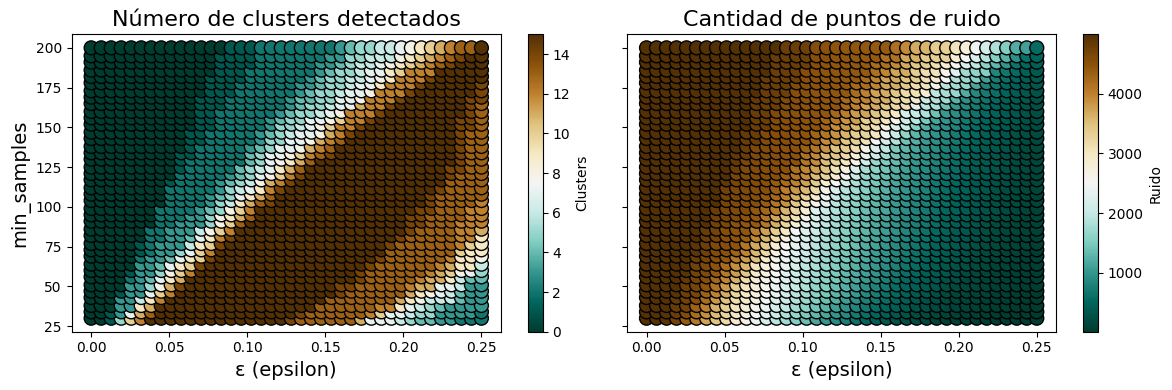

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sc1 = ax1.scatter(
    E_cpu, M_cpu,
    c=clusters.flatten(),
    cmap="BrBG_r",
    s=100,
    edgecolors="k"
)
ax1.set_title("Número de clusters detectados", fontsize=16)
ax1.set_xlabel("ε (epsilon)", fontsize=14)
ax1.set_ylabel("min_samples", fontsize=14)  
fig.colorbar(sc1, ax=ax1, label="Clusters")

sc2 = ax2.scatter(
    E_cpu, M_cpu,
    c=noise.flatten(),
    cmap="BrBG_r", #RdBu_r
    s=100,
    edgecolors="k"
)
ax2.set_title("Cantidad de puntos de ruido", fontsize=16)
ax2.set_xlabel("ε (epsilon)", fontsize=14)
fig.colorbar(sc2, ax=ax2, label="Ruido")

plt.tight_layout()
plt.show()

In [130]:
import numpy as np
from sklearn.metrics import silhouette_score

def penalized_silhouette(X, labels, alpha=1.0, lambd=0.0):
    """
    Calcula silhouette penalizada:
      silhouette * (1 - noise_frac)^alpha  -  lambd * noise_frac
    """
    N = len(labels)
    noise_mask = (labels == -1)
    noise_frac = noise_mask.sum() / N
    
    # Si queda menos de 2 clusters, silhouette_score falla: devolvemos -1
    unique_labels = set(labels) - {-1}
    if len(unique_labels) < 2:
        return -1.0
    
    # Compute silhouette only on non-noise
    sil = silhouette_score(X[~noise_mask], labels[~noise_mask])
    
    return sil * (1 - noise_frac)**alpha - lambd * noise_frac


# Supongamos que clusters y noise ya están calculados en tu grid search:
best_score = -np.inf
best_params = None

for i, min_pts in enumerate(min_pts_list):
    for j, eps in enumerate(eps_list):
        db = DBSCAN(eps=eps, min_samples=min_pts)
        labels = db.fit_predict(Xn_cpu)
        
        score = penalized_silhouette(
            Xn_cpu, labels,
            alpha=1.0,    # penalización lineal
            lambd=0.5     # peso extra al ruido
        )
        
        if score > best_score:
            best_score  = score
            best_params = (eps, min_pts, db.n_clusters_, int((labels==-1).sum()))

print(f"Mejor combinación: ε={best_params[0]:.4f}, "
      f"min_samples={best_params[1]} → "
      f"{best_params[2]} clusters, {best_params[3]} ruido, score={best_score:.3f}")


Mejor combinación: ε=0.2308, min_samples=130 → 15 clusters, 266 ruido, score=0.597


DBSCAN ε=0.2308, min_samples=130 → 15 clusters, 266 puntos de ruido (5.32% del total)


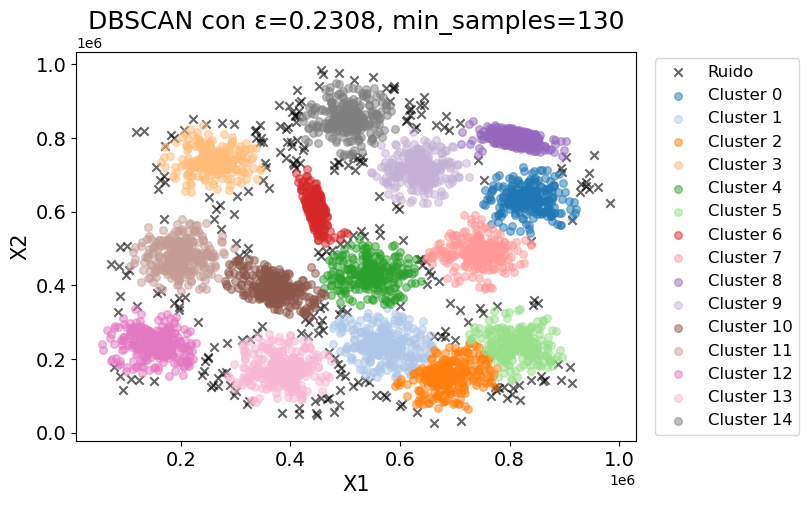

In [133]:
eps_new       = 0.2308
min_samples   = 130

Xn_cpu = cp.asnumpy(Xn)

db = DBSCAN(eps=eps_new, min_samples=min_samples)
labels_new = db.fit_predict(Xn_cpu) 

n_clusters = db.n_clusters_
n_noise    = int((labels_new == -1).sum())
total_pts  = labels_new.size
noise_pct  = 100 * n_noise / total_pts

print(
    f"DBSCAN ε={eps_new}, min_samples={min_samples} → "
    f"{n_clusters} clusters, {n_noise} puntos de ruido "
    f"({noise_pct:.2f}% del total)"
)

fig, ax = plt.subplots(figsize=(11,5))
cmap = plt.get_cmap("tab20")
for lab in sorted(set(labels_new.tolist())):
    mask = (labels_new == lab)
    if lab == -1:
        ax.scatter(X_cpu[mask,0], X_cpu[mask,1],
                   c='k', marker='x', label='Ruido', alpha=0.6)
    else:
        ax.scatter(X_cpu[mask,0], X_cpu[mask,1],
                   c=[cmap(lab%20)], s=30, label=f"Cluster {lab}", alpha=0.5)

ax.set_title(f"DBSCAN con ε={eps_new}, min_samples={min_samples}", fontsize=18)
ax.set_xlabel("X1", fontsize=15)
ax.set_ylabel("X2", fontsize=15)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), ncol=1, fontsize = 11.85)
plt.tight_layout(rect=(0,0,0.75,1))
plt.show()


##### Elección de una combinación de ε y K

In [121]:
eps_new       = 0.2
min_samples   = 86

In [ ]:
Xn_cpu = cp.asnumpy(Xn)

db = DBSCAN(eps=eps_new, min_samples=min_samples)
labels_new = db.fit_predict(Xn_cpu) 

n_clusters = db.n_clusters_
n_noise    = int((labels_new == -1).sum())
total_pts  = labels_new.size
noise_pct  = 100 * n_noise / total_pts

print(
    f"DBSCAN ε={eps_new}, min_samples={min_samples} → "
    f"{n_clusters} clusters, {n_noise} puntos de ruido "
    f"({noise_pct:.2f}% del total)"
)

DBSCAN ε=0.2, min_samples=86 → 15 clusters, 398 puntos de ruido (7.96% del total)


##### Gráfico de los datos

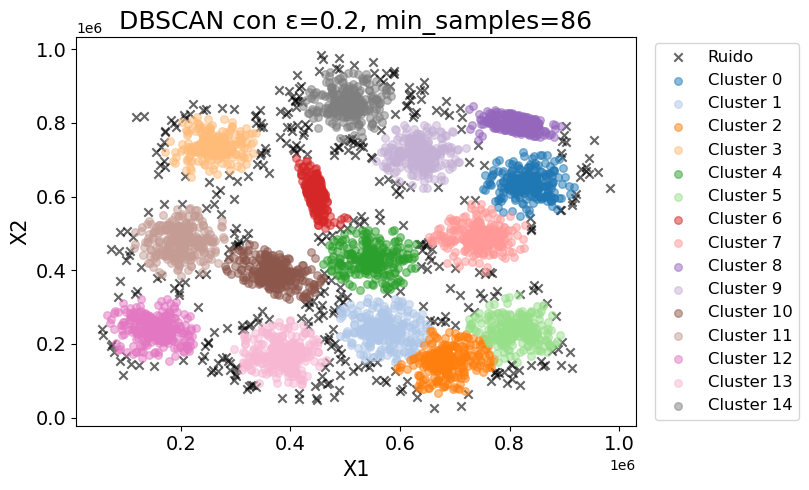

In [124]:
fig, ax = plt.subplots(figsize=(11,5))
cmap = plt.get_cmap("tab20")
for lab in sorted(set(labels_new.tolist())):
    mask = (labels_new == lab)
    if lab == -1:
        ax.scatter(X_cpu[mask,0], X_cpu[mask,1],
                   c='k', marker='x', label='Ruido', alpha=0.6)
    else:
        ax.scatter(X_cpu[mask,0], X_cpu[mask,1],
                   c=[cmap(lab%20)], s=30, label=f"Cluster {lab}", alpha=0.5)

ax.set_title(f"DBSCAN con ε={eps_new}, min_samples={min_samples}", fontsize=18)
ax.set_xlabel("X1", fontsize=15)
ax.set_ylabel("X2", fontsize=15)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), ncol=1, fontsize = 11.85)
plt.tight_layout(rect=(0,0,0.75,1))
plt.show()


##### Elección de una combinación de ε y K

In [67]:
eps_new       = 0.1575
min_samples   = 50

##### Gráfico de los datos

In [68]:
db = DBSCAN(eps=eps_new, min_samples=min_samples)
labels_new = db.fit_predict(Xn).get()

print(f"DBSCAN ε={eps_new}, min_samples={min_samples} → {db.n_clusters_} clusters, " +
      f"{int((labels_new==-1).sum())} puntos de ruido")

DBSCAN ε=0.1575, min_samples=50 → 15 clusters, 639 puntos de ruido


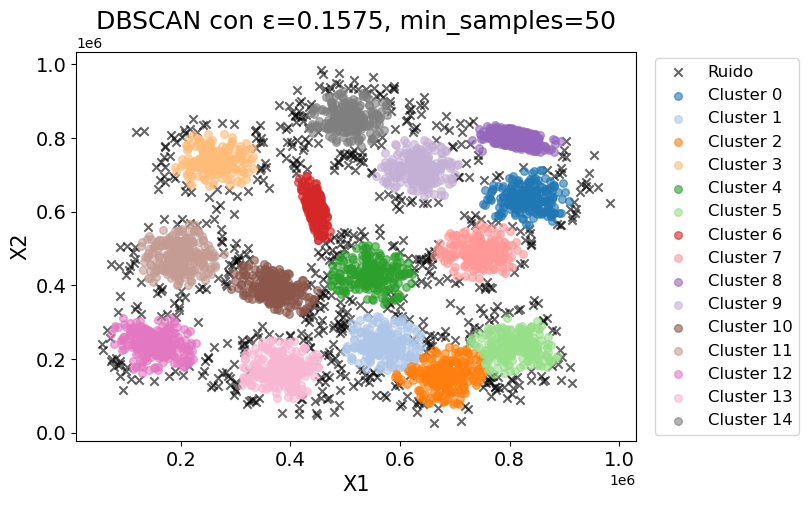

In [69]:
fig, ax = plt.subplots(figsize=(11,5))
cmap = plt.get_cmap("tab20")
for lab in sorted(set(labels_new.tolist())):
    mask = (labels_new == lab)
    if lab == -1:
        ax.scatter(X_cpu[mask,0], X_cpu[mask,1],
                   c='k', marker='x', label='Ruido', alpha=0.6)
    else:
        ax.scatter(X_cpu[mask,0], X_cpu[mask,1],
                   c=[cmap(lab%20)], s=30, label=f"Cluster {lab}", alpha=0.6)

ax.set_title(f"DBSCAN con ε={eps_new}, min_samples={min_samples}", fontsize=18)
ax.set_xlabel("X1", fontsize=15)
ax.set_ylabel("X2", fontsize=15)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), ncol=1, fontsize = 11.85)
plt.tight_layout(rect=(0,0,0.75,1))
plt.show()


## `2.` **Reducción de dimensionalidad**

##### Cargar los datos


In [70]:
import numpy as np

In [197]:
MNIST_path = "data/MNIST_dataset.csv"

MNIST_df = pd.read_csv(MNIST_path)
y = MNIST_df.iloc[:, 0].values.astype(int)
X_np = MNIST_df.iloc[:, 1:].values.astype(float) 
X = cp.array(X_np)


### `a.` **PCA**

In [72]:
from src.models import PCA

In [73]:
components = [10, 15, 30, 50, 87, 140, 200, 400, 784]
mse_list = []

for k in components:
    pca = PCA(n_components=k).fit(X)
    X_proj = pca.transform(X)
    X_rec = pca.inverse_transform(X_proj)

    mse_k = cp.mean((X - X_rec) ** 2)
    mse_list.append(mse_k.get())  # traemos a CPU para almacenar
    print(f"PCA k={k}: MSE = {mse_list[-1]:.4f}")

PCA k=10: MSE = 0.0344
PCA k=15: MSE = 0.0282
PCA k=30: MSE = 0.0181
PCA k=50: MSE = 0.0117
PCA k=87: MSE = 0.0067
PCA k=140: MSE = 0.0038
PCA k=200: MSE = 0.0023
PCA k=400: MSE = 0.0003
PCA k=784: MSE = 0.0000


##### Gráfico de cómo varía el error cuadrático medio de reconstrucción sobre el conjunto de datos en función de la cantidad de componentes principales utilizadas

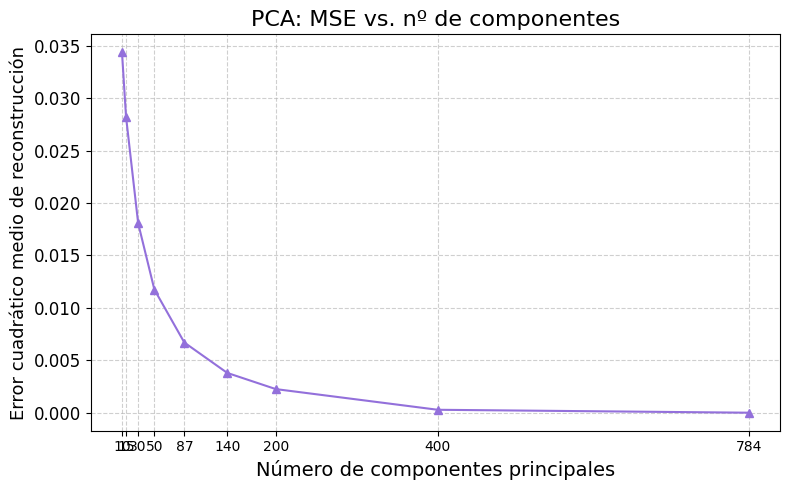

In [74]:
import numpy as _np 
plt.figure(figsize=(8,5))
plt.plot(components, _np.array(mse_list), marker='^', linewidth=1.5, color = "mediumpurple")
plt.xlabel('Número de componentes principales', fontsize=14)
plt.ylabel('Error cuadrático medio de reconstrucción', fontsize=13)
plt.title('PCA: MSE vs. nº de componentes', fontsize=16)
plt.yticks(fontsize=12)
plt.xticks(components, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### `b.` Selección de **componentes principales**

In [75]:
pca_full = PCA(n_components=X.shape[1]).fit(X)

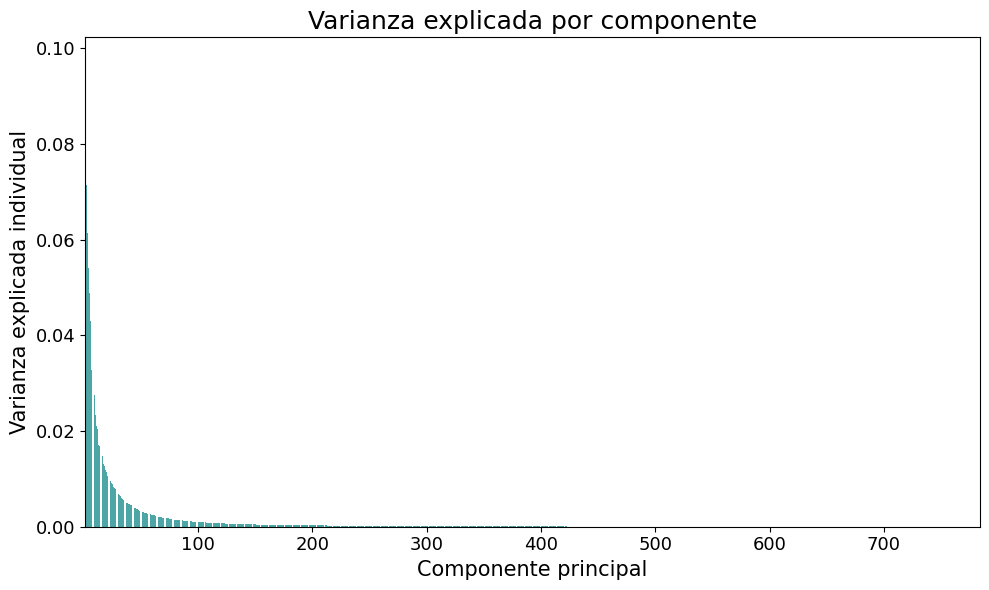

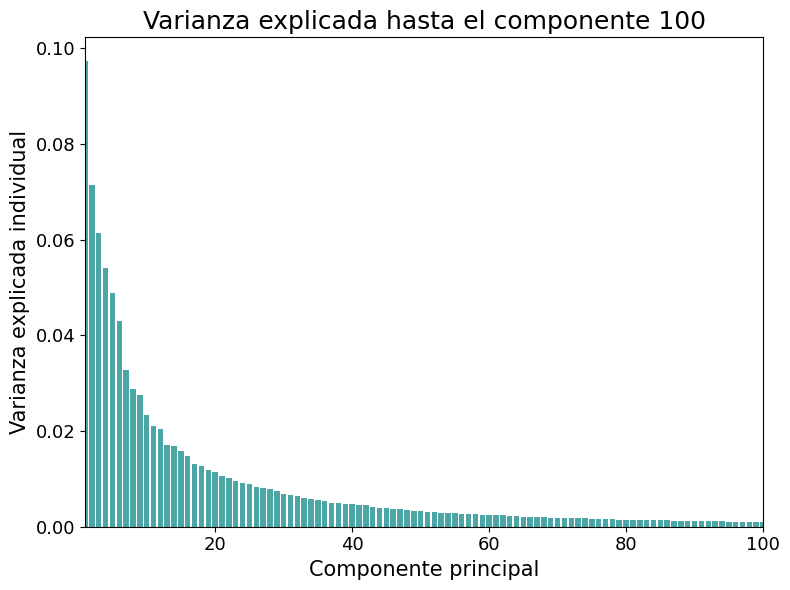

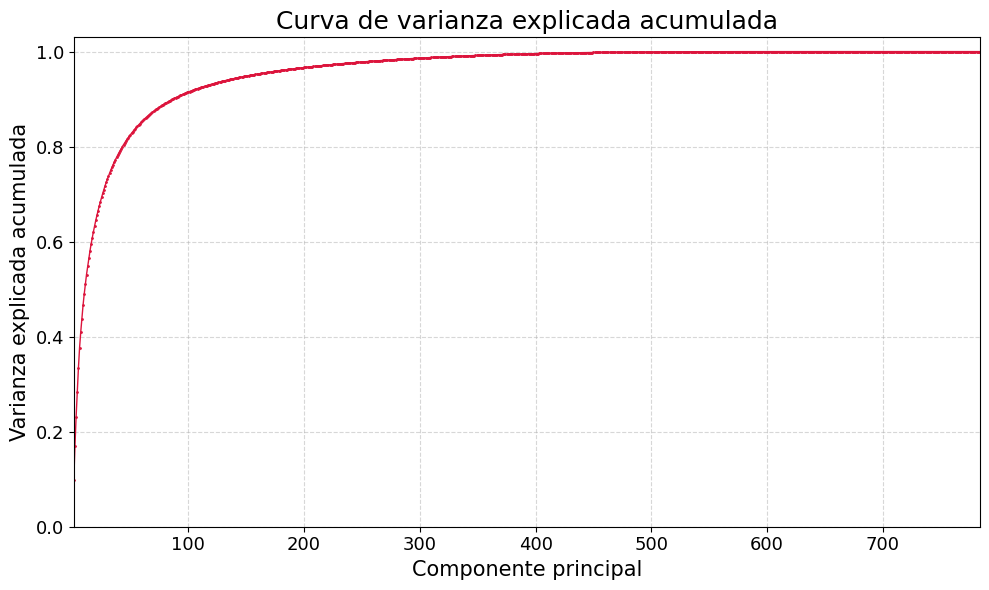

In [76]:
pca_full.plot_explained_variance()

##### Elegir k según varianza acumulada (90%)

In [200]:
cum_var = pca_full.cummulative_variance()
k_90 = int(cp.argmax(cum_var >= 0.80) + 1)
print(f"Componentes necesarias para 90% de varianza: {k_90}")

Componentes necesarias para 90% de varianza: 43


##### Gráfico de las imagenes de los digitos originales y reconstruidos para las primeras 10 muestras del dataset con 87 cantidad de componentes

In [189]:
pca_k = PCA(n_components=k_90).fit(X)
X_proj = pca_k.transform(X)
X_rec = pca_k.inverse_transform(X_proj)

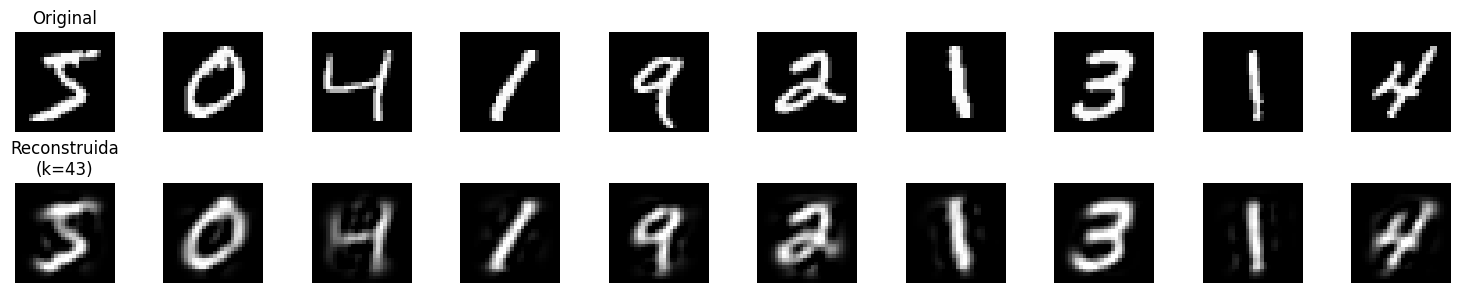

In [190]:
n_show = 10
originals = X[:n_show].get().reshape(n_show, 28, 28)
reconstructions = X_rec[:n_show].get().reshape(n_show, 28, 28)

fig, axes = plt.subplots(2, n_show, figsize=(n_show*1.5, 3))
for i in range(n_show):
    # fila 0: original
    axes[0, i].imshow(originals[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original')
    # fila 1: reconstruida
    axes[1, i].imshow(reconstructions[i], cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstruida\n(k=%d)' % k_90)
plt.tight_layout()
plt.show()

### `c.` Modelo de Autoencoder Variacional (**VAE**) usando PyTorch

##### División en entrenamiento y validación

In [80]:
import cupy as cp
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

In [81]:
from src.models import VAE

In [198]:
X_np_vae = MNIST_df.iloc[:, 1:].values.astype(np.float32) / 255.0 # normalizar a [0, 1]
# convertimos a Torch tensor
X_tensor = torch.from_numpy(X_np_vae)
dataset = TensorDataset(X_tensor, torch.from_numpy(y))

# 2) Split en train/val
val_frac = 0.1
n_val = int(len(dataset) * val_frac)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)


##### Entrenamiento

Epoch 01 — Train loss: 163.2203, Val loss: 128.8160
Epoch 02 — Train loss: 121.0186, Val loss: 117.0469
Epoch 03 — Train loss: 114.0407, Val loss: 113.1321
Epoch 04 — Train loss: 111.1002, Val loss: 110.9907
Epoch 05 — Train loss: 109.4014, Val loss: 109.7631
Epoch 06 — Train loss: 108.3361, Val loss: 108.8744
Epoch 07 — Train loss: 107.5123, Val loss: 108.2613
Epoch 08 — Train loss: 106.9086, Val loss: 107.8793
Epoch 09 — Train loss: 106.4426, Val loss: 107.2345
Epoch 10 — Train loss: 106.0186, Val loss: 107.0538
Epoch 11 — Train loss: 105.6906, Val loss: 106.5002
Epoch 12 — Train loss: 105.4317, Val loss: 106.3446
Epoch 13 — Train loss: 105.1554, Val loss: 105.8378
Epoch 14 — Train loss: 104.9337, Val loss: 105.7493
Epoch 15 — Train loss: 104.7050, Val loss: 105.6401
Epoch 16 — Train loss: 104.5543, Val loss: 105.8286
Epoch 17 — Train loss: 104.4086, Val loss: 105.6106
Epoch 18 — Train loss: 104.2261, Val loss: 105.5554
Epoch 19 — Train loss: 104.0698, Val loss: 105.1220
Epoch 20 — T

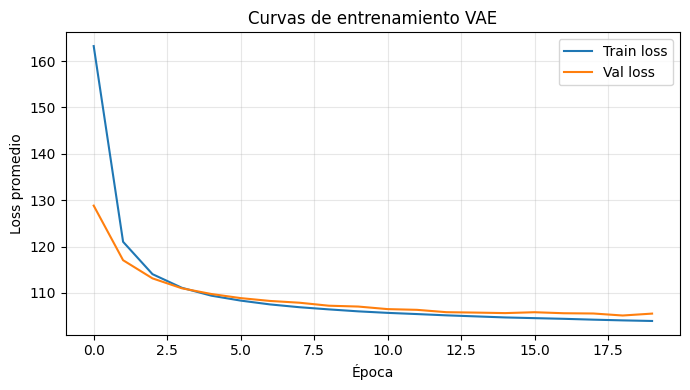

In [ ]:
from torch.utils.data import TensorDataset, random_split
from torch import from_numpy
import numpy as np
import pandas as pd

# 1) Cargar y normalizar datos
df      = pd.read_csv("data/MNIST_dataset.csv")
X_np_vae    = (df.iloc[:,1:].values / 255.0).astype(np.float32)
y_np_vae    = df.iloc[:,0].values.astype(int)
dataset = TensorDataset(from_numpy(X_np_vae), from_numpy(y_np_vae))

# 2) Split 90/10 train/val
n_val     = int(len(dataset) * 0.1)
n_train   = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(0))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)

# 3) Crear y entrenar
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=20)
train_losses, val_losses = vae.fit(train_loader, val_loader, n_epochs=20, lr=1e-3)

# 4) Mostrar curvas de pérdida
vae.plot_training_curves(train_losses, val_losses)


Epoch 01 — Train loss: 175.8702, Val loss: 165.4078
Epoch 02 — Train loss: 162.3642, Val loss: 163.2677
Epoch 03 — Train loss: 159.7808, Val loss: 160.5637
Epoch 04 — Train loss: 158.2425, Val loss: 158.5634
Epoch 05 — Train loss: 157.1942, Val loss: 157.7761
Epoch 06 — Train loss: 156.4407, Val loss: 157.9781
Epoch 07 — Train loss: 155.8395, Val loss: 158.2234
Epoch 08 — Train loss: 155.3475, Val loss: 156.6951
Epoch 09 — Train loss: 154.8359, Val loss: 156.7568
Epoch 10 — Train loss: 154.5873, Val loss: 156.7927
latent=2, hidden=200, lr=0.01 → val_loss=156.793
Epoch 01 — Train loss: 179.6988, Val loss: 166.5587
Epoch 02 — Train loss: 162.2499, Val loss: 161.9750
Epoch 03 — Train loss: 159.3909, Val loss: 160.7460
Epoch 04 — Train loss: 157.6801, Val loss: 159.1645
Epoch 05 — Train loss: 156.3572, Val loss: 158.0719
Epoch 06 — Train loss: 155.7527, Val loss: 157.4016
Epoch 07 — Train loss: 154.9520, Val loss: 157.0597
Epoch 08 — Train loss: 154.5706, Val loss: 155.5476
Epoch 09 — Trai

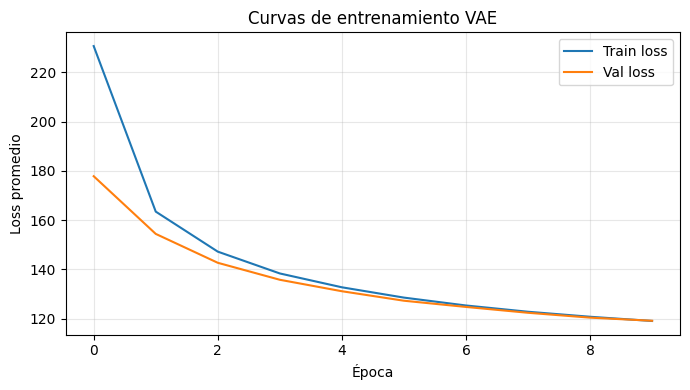

In [83]:
# 1) Primero: un mini-sweep para elegir latent_dim óptimo
best_cfg = None
best_val_loss = float('inf')

for latent_dim in [2, 5, 10, 20, 50]:
    for lr in [1e-2, 1e-3, 1e-4]:
        for hidden_dim in [200, 400, 800]:
            vae = VAE(input_dim=784, hidden_dim=hidden_dim, latent_dim=latent_dim)
            train_losses, val_losses = vae.fit(
                train_loader, val_loader,
                n_epochs=10,              # por ejemplo 10 épocas para el sweep
                lr=lr
            )
            final_val = val_losses[-1]
            print(f"latent={latent_dim}, hidden={hidden_dim}, lr={lr} → val_loss={final_val:.3f}")
            if final_val < best_val_loss:
                best_val_loss = final_val
                best_cfg = (latent_dim, hidden_dim, lr)

print("Mejor configuración encontrada:", best_cfg, "con val_loss=", best_val_loss)

# 2) Con la mejor config, re-entrenamos a conciencia
latent_dim, hidden_dim, lr = best_cfg
vae = VAE(input_dim=784, hidden_dim=hidden_dim, latent_dim=latent_dim)
vae.fit(train_loader, val_loader, n_epochs=20, lr=lr)  # más épocas
vae.plot_training_curves(train_losses, val_losses)

##### Comparación con PCA

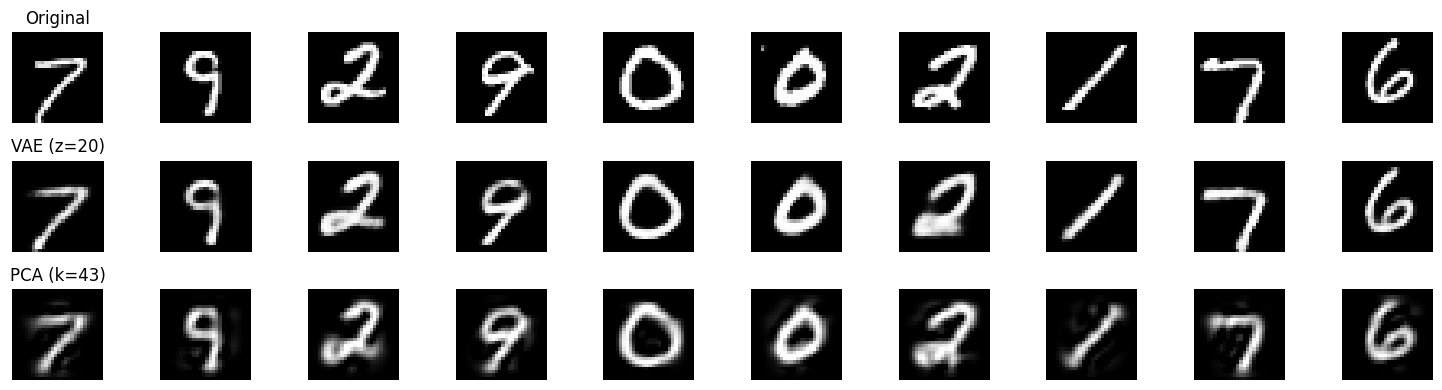

In [201]:

# 3) Entrenamiento PCA con el k_90 definido antes
X_vae = cp.array(X_np_vae)


pca_k = PCA(n_components=k_90).fit(X)

# 4) Selección de 10 muestras aleatorias de validación
val_indices = np.random.choice(len(val_loader.dataset), size=10, replace=False)

orig  = []
vae_r = []
pca_r = []

vae.eval()
with torch.no_grad():
    for idx in val_indices:
        x_orig = val_loader.dataset[idx][0].unsqueeze(0).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        # VAE
        x_rec_vae, _, _ = vae(x_orig)
        vae_r.append(x_rec_vae.cpu().squeeze().numpy())
        # PCA
        x_row = X_np[val_loader.dataset.indices[idx:idx+1]]
        x_gpu = cp.array(x_row)
        x_rec_pca = pca_k.inverse_transform(pca_k.transform(x_gpu)).get().squeeze()
        pca_r.append(x_rec_pca)
        orig.append(x_row.squeeze())

# 5) Plot comparativo
n = len(orig)
fig, axes = plt.subplots(3, n, figsize=(n*1.5, 4))
for i in range(n):
    axes[0,i].imshow(orig[i].reshape(28,28), cmap='gray')
    axes[0,i].axis('off')
    if i==0: axes[0,i].set_title("Original")

    axes[1,i].imshow(vae_r[i].reshape(28,28), cmap='gray')
    axes[1,i].axis('off')
    if i==0: axes[1,i].set_title(f"VAE (z={latent_dim})")

    axes[2,i].imshow(pca_r[i].reshape(28,28), cmap='gray')
    axes[2,i].axis('off')
    if i==0: axes[2,i].set_title(f"PCA (k={k_90})")

plt.tight_layout()
plt.show()